### Import Libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Loading Cleaned Dataset

In [5]:
df_cleaned_transaction_data = pd.read_parquet(r"C:\Users\leest\OneDrive\Data Projects\Amdari Projects\Digital_Transfer_Fraud_Detection_System\Datasets\Artifats\Cleaned_Finlora_Dataset.parquet")

### Setting a Consistent Visualisation Theme

In [20]:
# Set a clean, professional theme
sns.set_theme(
    style="white",
    context="notebook",
    font_scale=1.1
)

# Create a readable label column for is_fraud
df_cleaned_transaction_data["fraud_label"] = df_cleaned_transaction_data["is_fraud"].map({
    0: "Legitimate",
    1: "Fraud"
})

# Consistent color mapping for fraud analysis
fraud_palette = {
    "Legitimate": "#2E75B6",   # blue - calm/normal
    "Fraud": "#C0392B"         # red - alert/risk
}

# General palette for non-fraud-specific categorical plots (channel, currency, etc.)
sns.set_palette(["#2E75B6", "#C0392B", "#59A14F", "#F4A261", "#8E7CC3", "#4C4C4C"])

### The Fraud Landscape - Baseline Understanding
Establishing the scale of the problem before digging into drivers.

In [15]:
# Question 1 - How many customers and transactions are we looking at?

print(f"There are {df_cleaned_transaction_data["customer_id"].nunique()} customers and {df_cleaned_transaction_data["transaction_id"].nunique()} transactions represented in this dataset")

There are 1314 customers and 10940 transactions represented in this dataset


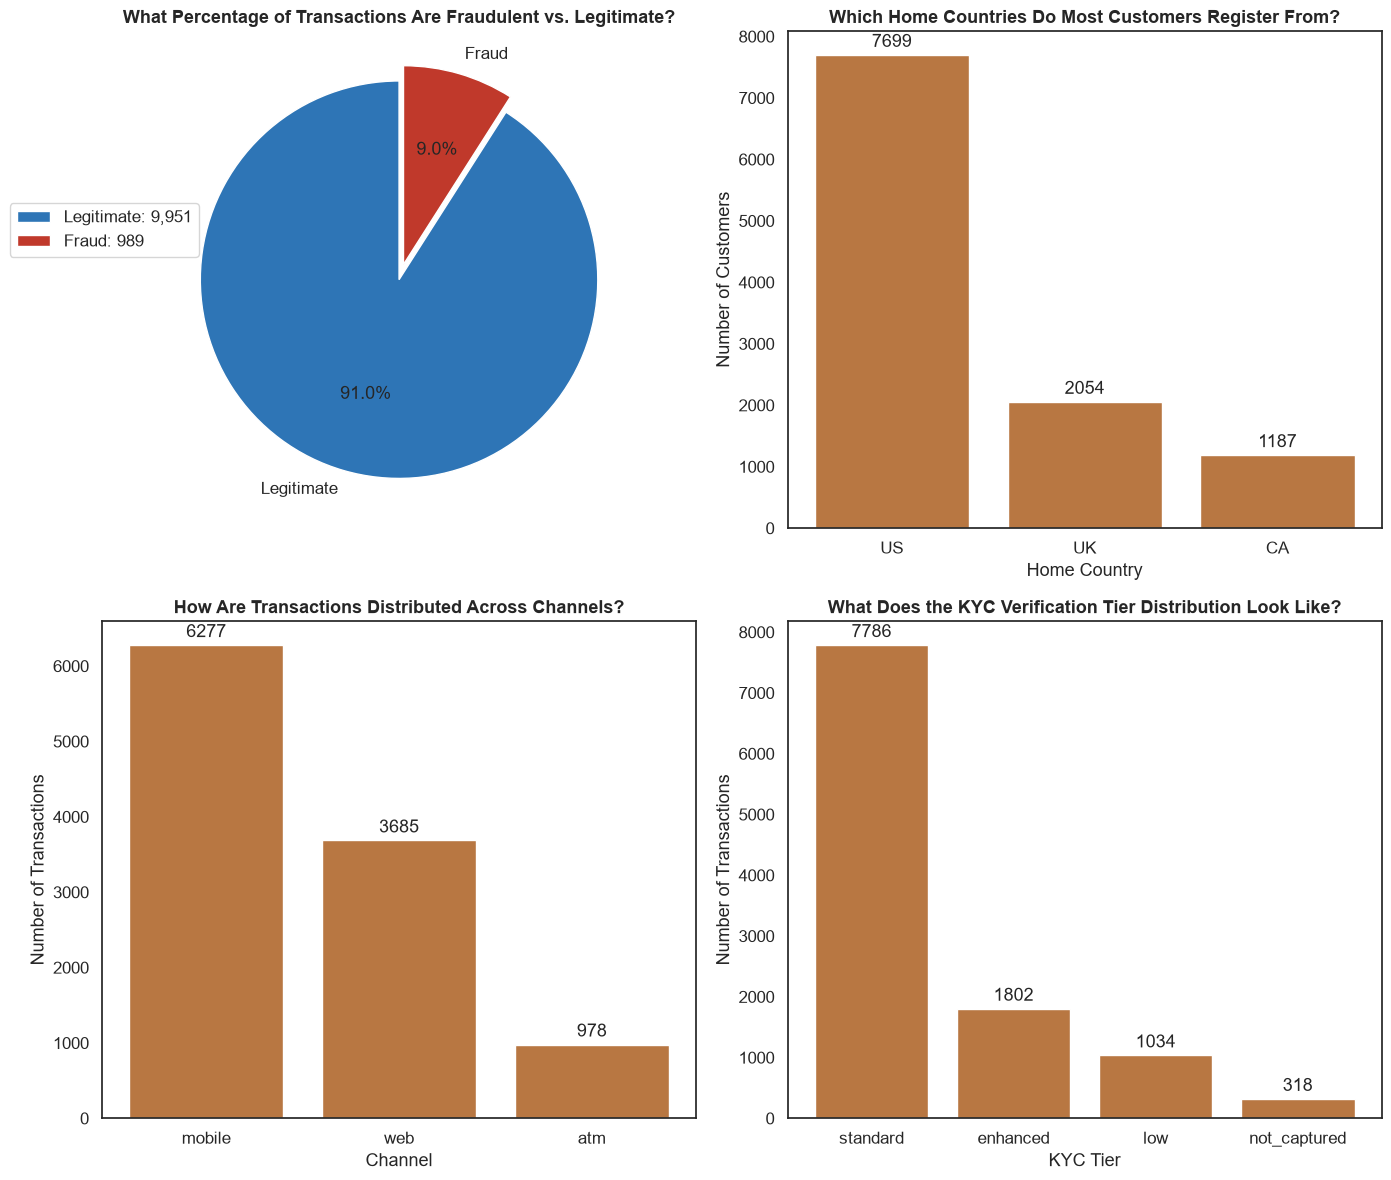

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

# Q2: What percentage of transactions are fraudulent vs. legitimate?
fraud_counts = df_cleaned_transaction_data["fraud_label"].value_counts()

wedges, texts, autotexts = axes[0].pie(
    fraud_counts,
    labels=fraud_counts.index,
    autopct="%1.1f%%",
    colors=[fraud_palette[label] for label in fraud_counts.index],
    startangle=90,
    explode=[0, 0.08]
)
axes[0].set_title("What Percentage of Transactions Are Fraudulent vs. Legitimate?")
axes[0].legend(
    wedges,
    [f"{label}: {count:,}" for label, count in fraud_counts.items()],
    loc="center left",
    bbox_to_anchor=(-0.3, 0.6)
)

# Q3: Which home countries do most customers register from?
country_counts = df_cleaned_transaction_data["home_country"].value_counts()
bars = axes[1].bar(country_counts.index, country_counts.values, color="#B87742")
axes[1].bar_label(bars, fmt="%d", padding=3)
axes[1].set_title("Which Home Countries Do Most Customers Register From?")
axes[1].set_xlabel("Home Country")
axes[1].set_ylabel("Number of Customers")

# Q4: How are transactions distributed across channels?
channel_counts = df_cleaned_transaction_data["channel"].value_counts()
bars = axes[2].bar(channel_counts.index, channel_counts.values, color="#B87742")
axes[2].bar_label(bars, fmt="%d", padding=3)
axes[2].set_title("How Are Transactions Distributed Across Channels?")
axes[2].set_xlabel("Channel")
axes[2].set_ylabel("Number of Transactions")

# Q5: What does the KYC verification tier distribution look like?
kyc_counts = df_cleaned_transaction_data["kyc_tier"].value_counts()
bars = axes[3].bar(kyc_counts.index, kyc_counts.values, color="#B87742")
axes[3].bar_label(bars, fmt="%d", padding=3)
axes[3].set_title("What Does the KYC Verification Tier Distribution Look Like?")
axes[3].set_xlabel("KYC Tier")
axes[3].set_ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

With 1,314 customers and 10,940 transactions in the cleaned dataset, this section establishes the baseline before digging into what drives fraud.

**Fraud is rare but material.** Fraudulent transactions make up **9.0%** of the dataset (989 of 10,940), against 91.0% legitimate. This confirms the class imbalance flagged in the project scope and will shape the modelling and evaluation approach going forward.

**Customers are concentrated in the US.** The majority of customers registered their account in the **US** (7,699), followed by the **UK** (2,054) and **CA** (1,187) — a skew worth keeping in mind when interpreting any geography-based fraud patterns later.

**Mobile is the dominant channel.** Most transactions occur via **mobile** (6,277), followed by **web** (3,685), with **ATM** transactions making up the smallest share (978).

**Most customers are standard-tier verified.** The majority of transactions come from **standard** KYC customers (7,786), with far fewer at **enhanced** (1,802) and **low** (1,034) tiers. Only **318** transactions fall under the **not_captured** placeholder, confirming this group is a small minority of the overall dataset.